In [1]:
from qibo.models.dbi.double_bracket import DoubleBracketIteration, DoubleBracketGeneratorType, DoubleBracketScheduling, DoubleBracketCostFunction
from qibo.models.dbi.utils import generate_pauli_operator_dict, decompose_into_pauli_basis, params_to_diagonal_operator, ParameterizationTypes
from copy import deepcopy
from qibo.models.dbi.utils_dbr_strategies import gradient_descent, gradient_descent_step
import numpy as np
from qibo import set_backend, hamiltonians
from qibo.hamiltonians import Hamiltonian
from qibo.quantum_info import random_hermitian
import matplotlib.pyplot as plt

In [2]:
def visualize_matrix(matrix, title=""):
    """Visualize hamiltonian in a heatmap form."""
    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_title(title)
    try:
        im = ax.imshow(np.absolute(matrix), cmap="inferno")
    except TypeError:
        im = ax.imshow(np.absolute(matrix.get()), cmap="inferno")
    fig.colorbar(im, ax=ax)

def s_hist_to_plot(s_hist):
    # convert list of step durations taken to plotable
    s_plot = [0] * len(s_hist)
    for i in range(len(s_hist)):
        if i != 0:
            s_plot[i] = s_plot[i-1] + s_hist[i]
    return s_plot

## Random hamiltonian

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
[Qibo 0.2.9|INFO|2024-06-04 16:43:26]: Using qibojit (numba) backend on /CPU:0


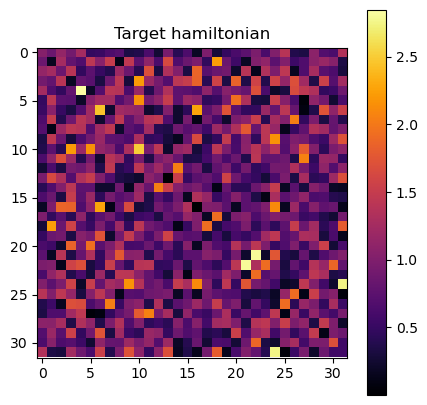

In [3]:
# set the qibo backend (we suggest qibojit if N >= 20)
set_backend("qibojit", platform="numba")

# hamiltonian parameters
nqubits = 5
seed = 10

# define the hamiltonian
h0 = random_hermitian(2**nqubits, seed=seed)
dbi = DoubleBracketIteration(
    Hamiltonian(nqubits, h0),
    mode=DoubleBracketGeneratorType.single_commutator,
    scheduling=DoubleBracketScheduling.hyperopt,
    cost=DoubleBracketCostFunction.off_diagonal_norm
)
# vosualize the matrix
visualize_matrix(dbi.h.matrix, title="Target hamiltonian")

In [4]:
# initialize Pauli-basis
pauli_operator_dict = generate_pauli_operator_dict(nqubits)
pauli_operators = list(pauli_operator_dict.values())
d_coef_pauli = np.ones(nqubits)

[Qibo 0.2.9|WARNING|2024-06-04 16:43:26]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-04 16:43:26]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-04 16:43:26]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-04 16:43:26]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-04 16:43:26]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.


In [5]:
# Use training to find a better d
train_space = np.linspace(1,501, 5)
for train_epochs in train_space:
    d_train_coef, d_train, s_train = gradient_descent_step(dbi, int(train_epochs), d_coef_pauli, ParameterizationTypes.pauli, pauli_operator_dict)
    print(dbi.loss(s_train, d_train))

28.220450268812606
28.223132798914378
28.093794720905777
28.100809863185763
28.057596740621463


In [7]:
d_train_coef, d_train, s_train = gradient_descent_step(dbi, int(train_epochs), d_coef_pauli, ParameterizationTypes.pauli, pauli_operator_dict)
print(dbi.loss(s_train, d_train))

27.898907073320544
